In [ ]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
N = 100
study_hours = np.random.uniform(1, 10, N)
sleep_hours = np.random.uniform(4, 9, N)
marks = 10 + 5 * study_hours + 3 * sleep_hours + np.random.normal(0, 2, N)

In [ ]:
with pm.Model() as model_1:
    beta_0 = pm.Normal('beta_0', mu=0, sigma=10)
    beta_1 = pm.Normal('beta_1', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=5)

    mu = beta_0 + beta_1 * study_hours

    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=marks)

    trace_1 = pm.sample(1000, return_inferencedata=True, progressbar=False)
    pm.sample_posterior_predictive(trace_1, extend_inferencedata=True, progressbar=False)

    # NEW: Explicitly compute the log-likelihood for WAIC/LOO
    pm.compute_log_likelihood(trace_1)

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,30.003,1.154,27.801,32.078,0.041,0.030,793.0,757.0,1.0
beta_1,4.925,0.195,4.544,5.285,0.007,0.006,809.0,809.0,1.0
sigma,5.269,0.383,4.627,6.041,0.011,0.009,1152.0,1069.0,1.0


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


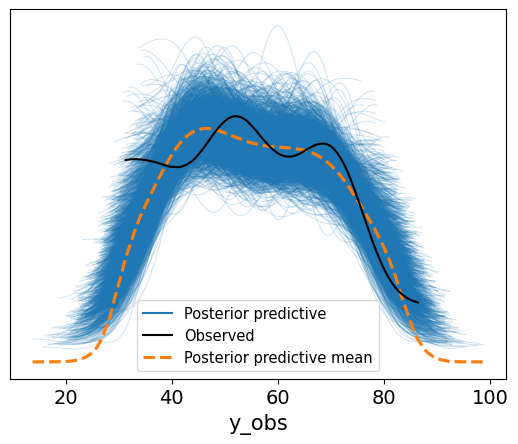

In [ ]:
display(az.summary(trace_1))
az.plot_ppc(trace_1)
plt.show()

In [ ]:
with pm.Model() as model_2:
    beta_0 = pm.Normal('beta_0', mu=0, sigma=10)
    beta_1 = pm.Normal('beta_1', mu=0, sigma=10)
    beta_2 = pm.Normal('beta_2', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=5)

    mu = beta_0 + beta_1 * study_hours + beta_2 * sleep_hours

    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=marks)

    trace_2 = pm.sample(1000, return_inferencedata=True, progressbar=False)
    pm.sample_posterior_predictive(trace_2, extend_inferencedata=True, progressbar=False)

    # NEW: Explicitly compute the log-likelihood for WAIC/LOO
    pm.compute_log_likelihood(trace_2)

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,8.725,0.988,6.947,10.644,0.032,0.031,973.0,884.0,1.0
beta_1,4.925,0.077,4.776,5.067,0.002,0.002,1438.0,1091.0,1.0
beta_2,3.289,0.136,3.025,3.520,0.004,0.004,1080.0,1125.0,1.0
sigma,2.000,0.151,1.731,2.272,0.004,0.004,1366.0,1100.0,1.0


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


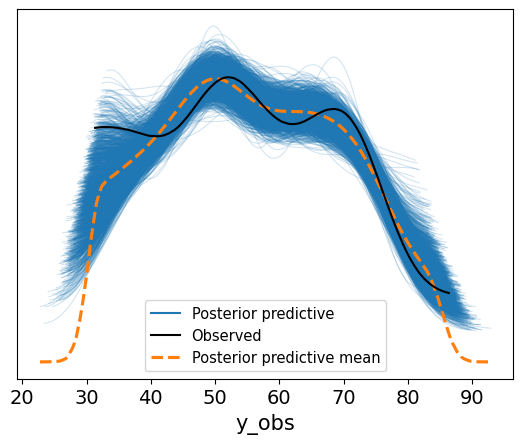

In [ ]:
display(az.summary(trace_2))
az.plot_ppc(trace_2)
plt.show()

In [ ]:
model_dict = {
    'Model 1 (Study)': trace_1,
    'Model 2 (Study + Sleep)': trace_2
}

comp_waic = az.compare(model_dict, ic="waic")
display(comp_waic)

comp_loo = az.compare(model_dict, ic="loo")
display(comp_loo)

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Model 2 (Study + Sleep),0,-212.786212,4.390745,0.000000,1.000000e+00,8.559406,0.000000,True,log
Model 1 (Study),1,-308.857958,2.287644,96.071746,6.008349e-11,5.452401,8.122762,False,log


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 2 (Study + Sleep),0,-212.801858,4.406392,0.000000,1.0,8.561816,0.000000,False,log
Model 1 (Study),1,-308.867372,2.297058,96.065514,0.0,5.453666,8.124866,False,log
